In [19]:
import pandas as pd
import geopandas 
# import rasterio
# from rasterio.plot import show
import contextily as cx
import folium
import matplotlib.pyplot as plt

res = 7

It was easier to calculate the polygons overlaps in qGIS. I copied the python commands generated by qGIS for each step of the process and pasted them here. `$REPO_PATH` should point to wherever this repositories directory lives on your machine

First we merge the tree canopy polygon layers for Montgomery and Prince George's Counties:
```
processing.run("native:mergevectorlayers", {'LAYERS':['$REPO_PATH/Datasets/Exported_TreeCanopyRasters/MC_TreeCanopyRasters_Poly.gdb|layername=tcdm2023','$REPO_PATH/Datasets/Tree_canopy_2023_Py.gdb|layername=Tree_canopy_2023_Py'],'CRS':QgsCoordinateReferenceSystem('EPSG:3857'),'OUTPUT':'$REPO_PATH/EDA/qGIS/tree_canopy_poly_merged.gpkg','ADD_SOURCE_FIELDS':True})
```

Then fix those geometries:
```
processing.run("native:fixgeometries", {'INPUT':'$REPO_PATH/EDA/qGIS/tree_canopy_poly_merged.gpkg|layername=tree_canopy_poly_merged','METHOD':1,'OUTPUT':'$REPO_PATH/EDA/qGIS/tree_canopy_poly_merged_and_fixed.gpkg'})

```

Now polyfill MC and PGC with h3 hexagons at resolution 7 (required having the H3Toolkit plugin installed):
```
processing.run("h3:createh3gridinsidepolygons", {'INPUT':'arcgisfeatureserver:// url=\'https://mdgeodata.md.gov/imap/rest/services/Boundaries/MD_PoliticalBoundaries/MapServer/1\' sql="COUNTY" = \'Montgomery\' OR "COUNTY" = \'Prince George\'\'s\'','RESOLUTION':7,'OUTPUT':'$REPO_PATH/EDA/qGIS/h3_07.gpkg'})
```

Finally calculate the vector overlaps:
```
processing.run("native:calculatevectoroverlaps", {'INPUT':'$REPO_PATH/EDA/qGIS/h3_07.gpkg|layername=h3_07','LAYERS':['$REPO_PATH/EDA/qGIS/tree_canopy_poly_merged_and_fixed.gpkg|layername=tree_canopy_poly_merged_and_fixed'],'OUTPUT':'$REPO_PATH/EDA/qGIS/h3_07_tree_canopy_overlap.gpkg','GRID_SIZE':None})
```

In [ ]:

h3_tree_canopy_overlap_df = geopandas.read_file("qGIS/h3_07_tree_canopy_overlap.gpkg")
h3_tree_canopy_overlap_df.head()

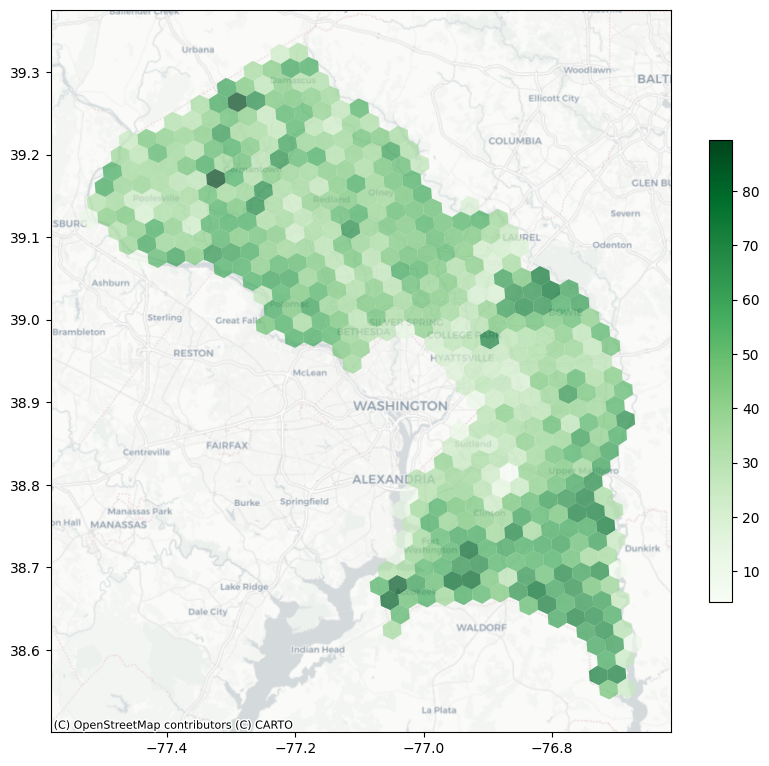

In [21]:
ax = h3_tree_canopy_overlap_df.plot(
    column='canopy_pct',
    figsize=(10, 10),
    cmap='Greens',
    alpha=0.7,
    legend=True,
    legend_kwds={'shrink': 0.6}
)
cx.add_basemap(ax, crs=h3_tree_canopy_overlap_df.crs, source=cx.providers.CartoDB.Positron, zoom=10)

In [ ]:
m = folium.Map(tiles="CartoDB Positron")
# folium.GeoJson(h3_tree_canopy_overlap_df).add_to(m)

# m.fit_bounds(m.get_bounds())


folium.Choropleth(
    geo_data=h3_tree_canopy_overlap_df,
    data=h3_tree_canopy_overlap_df,
    columns=[f"index", "canopy_pct"],
    fill_color="Greens",
    line_color=None,
    key_on=f"feature.properties.index",
    highlight=True,
).add_to(m)


m.fit_bounds(m.get_bounds())

m

# If you're using vscode and get a message about need to trust this notebook, or if the basemap doesn't load correctly, try adding an empty markdown cell after this (or delete and recreate, if one already exists)

Test